In [1]:
# Cauvery River Particulate Organic Carbon (POC) Analysis using Google Earth Engine and Aqua-OC

## MSc Geography Dissertation

### Student
Atul Kumar

### University
Central University of Haryana

---

## Objective

The objective of this notebook is to estimate the spatial and temporal distribution of Particulate Organic Carbon (POC) in the Cauvery River using satellite remote sensing and the Aqua-OC model.

The workflow includes:

1. Loading HydroRIVERS
2. Extracting the Cauvery River
3. Creating sampling points every 10 km
4. Processing Landsat imagery
5. Applying the Aqua-OC model
6. Extracting POC values
7. Computing POC Flux
8. Statistical analysis
9. Preparing publication-quality maps and figures

---

## Software

- Google Earth Engine
- Python
- Geemap
- JupyterLab

---

## Coordinate Reference System

EPSG:4326 (WGS84)

SyntaxError: invalid syntax (2202750226.py, line 6)

In [ ]:
Section 1.1 – Standard Setup (Code Cell)

In [6]:
# ============================================================
# CAUVERY RIVER POC ANALYSIS
# Standard Setup
# ============================================================

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Initialize Earth Engine
ee.Initialize(project="oc-flux")

# Interactive map
Map = geemap.Map()

print("Google Earth Engine Initialized Successfully")

Google Earth Engine Initialized Successfully


In [ ]:
Section 1.2 – Display Map (Code Cell)

In [7]:
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
Section 2.0 – Load HydroRIVERS (Markdown Cell)

In [ ]:
# 2.0 Load HydroRIVERS Dataset

HydroRIVERS is a global river network dataset that provides river geometry and attributes such as:

- River ID
- River Order
- Average Discharge
- River Length
- Catchment Area

In this study, HydroRIVERS is used to extract the Cauvery River.

In [ ]:
Section 2.1 – Load HydroRIVERS (Code Cell)

In [8]:
rivers = ee.FeatureCollection(
    "projects/oc-flux/assets/HydroRIVERS_v10_asi_shp"
)

print("Dataset Loaded")

Dataset Loaded


In [ ]:
Section 2.2 – Dataset Information (Code Cell)

In [9]:
print("Number of River Segments")

print(rivers.size().getInfo())

Number of River Segments
1428959


In [ ]:
Section 2.3 – Display HydroRIVERS (Code Cell)

In [10]:
Map.addLayer(
    rivers,
    {"color": "blue"},
    "HydroRIVERS"
)

Map

Map(bottom=812.0, center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [ ]:
Section 2.4 – Extract Cauvery River (Markdown Cell)

In [ ]:
## Why use MAIN_RIV?

HydroRIVERS stores rivers as many connected segments.

Each segment belonging to the same main river shares a common MAIN_RIV value.

For the Cauvery River:

MAIN_RIV = 41376077

Filtering by this value extracts the entire main river from source to mouth.

In [ ]:
Section 2.5 – Extract Cauvery (Code Cell)

In [11]:
cauvery = rivers.filter(
    ee.Filter.eq("MAIN_RIV", 41376077)
)

print("Number of Cauvery Segments")

print(cauvery.size().getInfo())

Number of Cauvery Segments
4549


In [ ]:
Section 2.6 – Display Cauvery (Code Cell)

In [12]:
Map.centerObject(cauvery, 7)

Map.addLayer(
    cauvery,
    {"color": "red"},
    "Cauvery River"
)

Map

Map(bottom=15600.0, center=[11.827342125848073, 77.2170751944037], controls=(WidgetControl(options=['position'…

In [ ]:
Section 2.7 – River Attributes (Code Cell)

In [13]:
feature = cauvery.first()

print("Available Attributes:")

print(feature.propertyNames().getInfo())

print("\nSample Attribute Values:")

print(feature.toDictionary().getInfo())

Available Attributes:
['MAIN_RIV', 'UPLAND_SKM', 'ORD_CLAS', 'LENGTH_KM', 'CATCH_SKM', 'ORD_STRA', 'DIST_DN_KM', 'ORD_FLOW', 'NEXT_DOWN', 'DIST_UP_KM', 'HYRIV_ID', 'DIS_AV_CMS', 'ENDORHEIC', 'HYBAS_L12', 'system:index']

Sample Attribute Values:
{'CATCH_SKM': 49.24, 'DIST_DN_KM': 9.3, 'DIST_UP_KM': 17.5, 'DIS_AV_CMS': 0.714, 'ENDORHEIC': 0, 'HYBAS_L12': 4120028760, 'HYRIV_ID': 41376076, 'LENGTH_KM': 12.43, 'MAIN_RIV': 41376077, 'NEXT_DOWN': 41376077, 'ORD_CLAS': 2, 'ORD_FLOW': 7, 'ORD_STRA': 1, 'UPLAND_SKM': 49.2}


In [ ]:
3.0 River Geometry Preparation (Markdown Cell)

In [ ]:
# 3.0 River Geometry Preparation

HydroRIVERS stores a river as thousands of individual line segments.

Before creating sampling points, these segments must be merged into one continuous geometry.

This section will:

- Merge all Cauvery segments
- Calculate total river length
- Inspect the river geometry
- Prepare the river for sampling every 10 km

This geometry will be used throughout the remaining analysis.

In [ ]:
3.1 Merge River Segments (Code Cell)

In [14]:
# Merge all Cauvery segments into one geometry

river = cauvery.geometry()

print("River geometry created successfully.")

River geometry created successfully.


In [ ]:
3.2 Display Merged Geometry (Code Cell)
Expected Result

You should see:

Blue = HydroRIVERS
Red = Cauvery
Yellow = Merged geometry

The yellow line should completely overlap the red river.

In [15]:
Map.addLayer(
    river,
    {
        "color": "yellow"
    },
    "Merged Cauvery Geometry"
)

Map

Map(bottom=15600.0, center=[11.827342125848073, 77.2170751944037], controls=(WidgetControl(options=['position'…

In [ ]:
3.3 Calculate River Length (Markdown Cell)

In [ ]:
## Why Calculate River Length?

The river length is required to determine:

- Number of sampling points
- Sampling interval
- Distance along the river
- Longitudinal analysis

Earth Engine measures geometry length in metres.

In [ ]:
3.4 Measure River Length (Code Cell)

In [16]:
river_length = river.length()

river_length_m = river_length.getInfo()

print(f"River Length: {river_length_m:,.2f} metres")

print(f"River Length: {river_length_m/1000:.2f} km")

River Length: 18,637,286.91 metres
River Length: 18637.29 km


In [ ]:
3.5 Estimate Number of Sampling Points (Markdown Cell)

In [ ]:
## Why 10 km?

A 10 km spacing provides:

- Good spatial representation
- Fast computation
- Manageable dataset
- Suitable density for river-scale remote sensing

Estimated number of points:

Number of Points = River Length / 10 km

In [ ]:
3.6 Calculate Estimated Points (Code Cell)

In [17]:
spacing = 10000   # metres

estimated_points = int(river_length_m // spacing) + 1

print("Sampling Interval:", spacing/1000, "km")

print("Estimated Sampling Points:", estimated_points)

Sampling Interval: 10.0 km
Estimated Sampling Points: 1864


In [ ]:
3.7 Check River Bounds (Code Cell)
Why?

This gives the bounding rectangle of the river, which is useful later when filtering Landsat imagery to only the area of interest.

In [18]:
bounds = river.bounds()

Map.addLayer(
    bounds,
    {"color": "green"},
    "River Bounds"
)

Map

Map(bottom=15600.0, center=[11.827342125848073, 77.2170751944037], controls=(WidgetControl(options=['position'…

In [ ]:
3.8 Inspect River Geometry Type (Code Cell)

In [19]:
print("Geometry Type:")

print(river.type().getInfo())

Geometry Type:
MultiLineString


In [ ]:
3.9 Summary (Markdown Cell)

In [ ]:
# Summary

In this section we:

✔ Merged all Cauvery river segments

✔ Created a single river geometry

✔ Measured river length

✔ Estimated the number of sampling points

✔ Visualized the river geometry

The river is now ready for creation of the 10 km sampling network.

In [ ]:
4.0 Sampling Point Generation (Markdown Cell)

In [ ]:
# 4.0 Generate Sampling Points

## Objective

Generate sampling points every **10 km** along the Cauvery River.

These sampling points will later be used to:

- Extract Landsat reflectance
- Apply the Aqua-OC model
- Estimate POC
- Calculate POC Flux
- Perform longitudinal analysis

Because the Earth Engine Python API cannot reliably interpolate points along large MultiLineString geometries, this step is performed using GeoPandas and Shapely.

In [2]:
4.1 Standard Imports (Code Cell)

SyntaxError: invalid syntax (604697926.py, line 1)

In [20]:
import geopandas as gpd
import pandas as pd
import numpy as np

from shapely.geometry import LineString
from shapely.ops import linemerge

In [ ]:
4.2 Section 4.2 — Load the Cauvery Basin Boundary

In [168]:
import glob

glob.glob(r"G:\OCR\hydroriver\**\*.shp", recursive=True)

['G:\\OCR\\hydroriver\\Cauvery_50km_SamplingPoints.shp',
 'G:\\OCR\\hydroriver\\Cauvery_Rivers.shp',
 'G:\\OCR\\hydroriver\\Main_Cauvery.shp',
 'G:\\OCR\\hydroriver\\hybas_as_lev01-12_v1c\\hybas_as_lev01_v1c.shp',
 'G:\\OCR\\hydroriver\\hybas_as_lev01-12_v1c\\hybas_as_lev02_v1c.shp',
 'G:\\OCR\\hydroriver\\hybas_as_lev01-12_v1c\\hybas_as_lev03_v1c.shp',
 'G:\\OCR\\hydroriver\\hybas_as_lev01-12_v1c\\hybas_as_lev04_v1c.shp',
 'G:\\OCR\\hydroriver\\hybas_as_lev01-12_v1c\\hybas_as_lev05_v1c.shp',
 'G:\\OCR\\hydroriver\\hybas_as_lev01-12_v1c\\hybas_as_lev06_v1c.shp',
 'G:\\OCR\\hydroriver\\hybas_as_lev01-12_v1c\\hybas_as_lev07_v1c.shp',
 'G:\\OCR\\hydroriver\\hybas_as_lev01-12_v1c\\hybas_as_lev08_v1c.shp',
 'G:\\OCR\\hydroriver\\hybas_as_lev01-12_v1c\\hybas_as_lev09_v1c.shp',
 'G:\\OCR\\hydroriver\\hybas_as_lev01-12_v1c\\hybas_as_lev10_v1c.shp',
 'G:\\OCR\\hydroriver\\hybas_as_lev01-12_v1c\\hybas_as_lev11_v1c.shp',
 'G:\\OCR\\hydroriver\\hybas_as_lev01-12_v1c\\hybas_as_lev12_v1c.shp',
 'G:\

In [169]:
import geopandas as gpd

shp_path = r"G:\OCR\hydroriver\HydroRIVERS_v10_as_shp\HydroRIVERS_v10_as.shp"

rivers = gpd.read_file(shp_path)

print(rivers.head())

   HYRIV_ID  NEXT_DOWN  MAIN_RIV  LENGTH_KM  DIST_DN_KM  DIST_UP_KM  \
0  40000001   40000019  40017702       2.48      3056.6         6.9   
1  40000002   40000019  40017702       1.23      3056.8         6.0   
2  40000003   40000015  40017702       1.26      3052.8         7.4   
3  40000004   40000015  40017702       1.30      3052.6         7.9   
4  40000005   40000004  40017702       0.69      3054.1         6.4   

   CATCH_SKM  UPLAND_SKM  ENDORHEIC  DIS_AV_CMS  ORD_STRA  ORD_CLAS  ORD_FLOW  \
0      14.93        14.9          0       0.133         1         5         7   
1      12.76        12.8          0       0.120         1         6         7   
2      11.80        11.8          0       0.100         1         7         7   
3       2.17        24.9          0       0.195         2         6         7   
4      10.84        10.8          0       0.090         1         7         8   

    HYBAS_L12                                           geometry  
0  4121166050  LINE

In [170]:
import os

folder = r"G:\OCR\HydroBASINS"

for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith(".shp"):
            print(os.path.join(root, file))

In [ ]:
Load HydroBASINS Level 12

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
Load the Level 12 basin polygons

In [25]:
basins = gpd.read_file(
    r"G:\OCR\hydroriver\hybas_as_lev01-12_v1c\hybas_as_lev12_v1c.shp"
)

In [26]:
print("Number of basins:", len(basins))
print()

print("Columns:")
print(basins.columns.tolist())

Number of basins: 160508

Columns:
['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK', 'DIST_MAIN', 'SUB_AREA', 'UP_AREA', 'PFAF_ID', 'ENDO', 'COAST', 'ORDER', 'SORT', 'geometry']


In [27]:
basins.head()

,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry
0,4120000010,0,4120000010,4120000010,0.0,0.0,184.9,185.0,421010001000,0,1,0,1,"POLYGON ((135.81667 55.18333, 135.81667 55.187..."
1,4120000020,0,4120000020,4120000020,0.0,0.0,237.3,237.3,421010002000,0,0,1,2,"POLYGON ((135.81667 55.18333, 135.8125 55.1833..."
2,4120000030,0,4120000030,4120000030,0.0,0.0,36.5,36.5,421010003000,0,1,0,3,"POLYGON ((135.67083 55.12083, 135.67083 55.125..."
3,4120000040,0,4120000040,4120000040,0.0,0.0,219.2,219.2,421010004000,0,0,1,4,"POLYGON ((135.67083 55.12083, 135.66841 55.121..."
4,4120000050,0,4120000050,4120000050,0.0,0.0,17.9,17.9,421010005000,0,1,0,5,"POLYGON ((135.5875 55.1, 135.58715 55.10242, 1..."


In [28]:
print(basins.crs)

EPSG:4326


In [29]:
print(basins.crs)

EPSG:4326


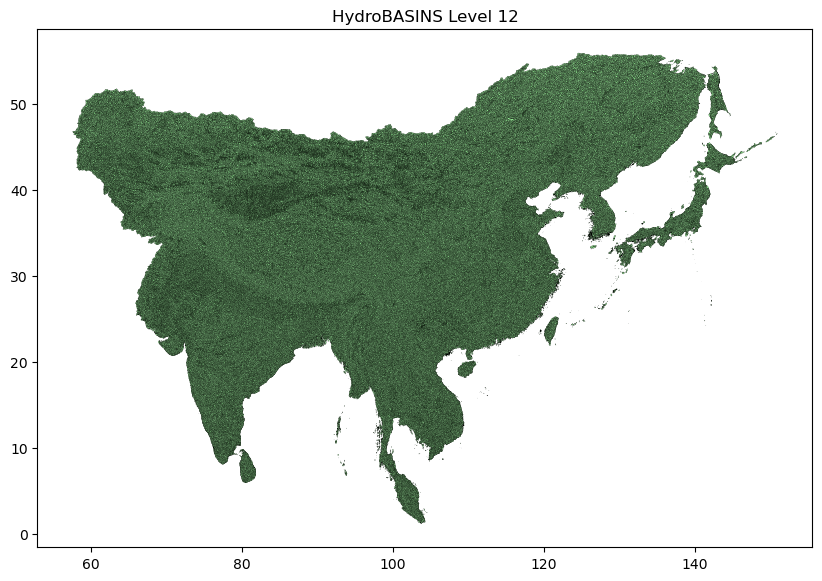

In [30]:
fig, ax = plt.subplots(figsize=(10,10))

basins.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightgreen",
    linewidth=0.15
)

plt.title("HydroBASINS Level 12")
plt.show()

In [31]:
print(basins.columns.tolist())

['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK', 'DIST_MAIN', 'SUB_AREA', 'UP_AREA', 'PFAF_ID', 'ENDO', 'COAST', 'ORDER', 'SORT', 'geometry']


In [32]:
print(basins.head())

     HYBAS_ID  NEXT_DOWN   NEXT_SINK    MAIN_BAS  DIST_SINK  DIST_MAIN  \
0  4120000010          0  4120000010  4120000010        0.0        0.0   
1  4120000020          0  4120000020  4120000020        0.0        0.0   
2  4120000030          0  4120000030  4120000030        0.0        0.0   
3  4120000040          0  4120000040  4120000040        0.0        0.0   
4  4120000050          0  4120000050  4120000050        0.0        0.0   

   SUB_AREA  UP_AREA       PFAF_ID  ENDO  COAST  ORDER  SORT  \
0     184.9    185.0  421010001000     0      1      0     1   
1     237.3    237.3  421010002000     0      0      1     2   
2      36.5     36.5  421010003000     0      1      0     3   
3     219.2    219.2  421010004000     0      0      1     4   
4      17.9     17.9  421010005000     0      1      0     5   

                                            geometry  
0  POLYGON ((135.81667 55.18333, 135.81667 55.187...  
1  POLYGON ((135.81667 55.18333, 135.8125 55.1833...  
2  PO

In [ ]:
Section 4.3 – Identify the Cauvery Basin Automatically

In [33]:
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
Step 1 – Create a Point on the Cauvery

In [34]:
cauvery_point = Point(76.65, 12.30)

In [ ]:
Step 2 – Convert to GeoDataFrame

In [35]:
point = gpd.GeoDataFrame(
    geometry=[cauvery_point],
    crs="EPSG:4326"
)

In [ ]:
Step 3 – Find the Basin

In [36]:
cauvery_basin = basins[basins.contains(cauvery_point)]

print(cauvery_basin)

         HYBAS_ID   NEXT_DOWN   NEXT_SINK    MAIN_BAS  DIST_SINK  DIST_MAIN  \
91042  4121140710  4121140690  4120028760  4120028760      596.8      596.8   

       SUB_AREA  UP_AREA       PFAF_ID  ENDO  COAST  ORDER   SORT  \
91042     155.2    336.2  453808010410     0      0      3  91043   

                                                geometry  
91042  POLYGON ((76.625 12.2375, 76.62585 12.24082, 7...  


In [ ]:
Step 4 – Plot

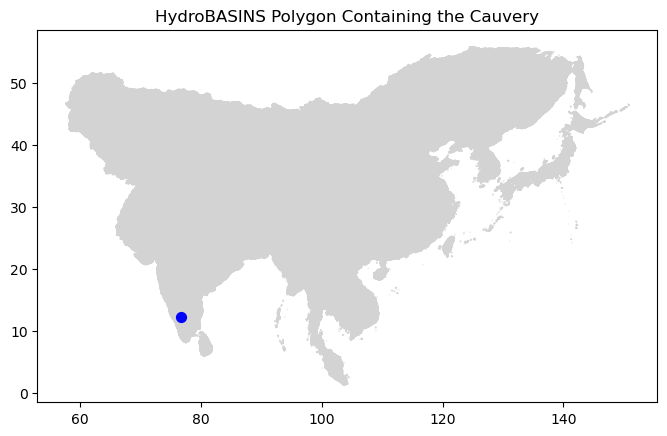

In [37]:
fig, ax = plt.subplots(figsize=(8,8))

basins.plot(ax=ax,
            facecolor="white",
            edgecolor="lightgray")

cauvery_basin.plot(ax=ax,
                   color="red")

point.plot(ax=ax,
           color="blue",
           markersize=50)

plt.title("HydroBASINS Polygon Containing the Cauvery")
plt.show()

In [ ]:
Step 5 – Check the Basin ID

In [38]:
print(cauvery_basin[["HYBAS_ID", "PFAF_ID", "UP_AREA"]])

         HYBAS_ID       PFAF_ID  UP_AREA
91042  4121140710  453808010410    336.2


In [ ]:
Part 4.4 – Find the Complete Cauvery Basin

In [ ]:
Step 1 – Load Level 5

In [39]:
basins5 = gpd.read_file(
    r"G:\OCR\hydroriver\hybas_as_lev01-12_v1c\hybas_as_lev05_v1c.shp"
)

In [40]:
print(basins5.crs)

EPSG:4326


In [41]:
cauvery5 = basins5[basins5.contains(cauvery_point)]

print(cauvery5[["HYBAS_ID","PFAF_ID","UP_AREA"]])

       HYBAS_ID  PFAF_ID  UP_AREA
416  4050028760    45380  78369.8


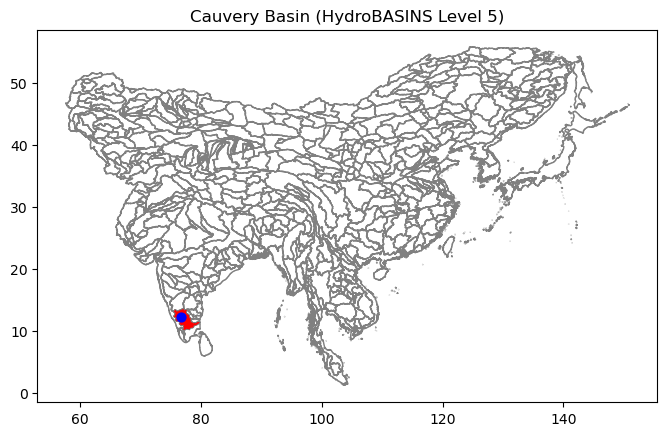

In [42]:
fig, ax = plt.subplots(figsize=(8,8))

basins5.plot(
    ax=ax,
    edgecolor="gray",
    facecolor="white"
)

cauvery5.plot(
    ax=ax,
    color="red"
)

point.plot(
    ax=ax,
    color="blue",
    markersize=40
)

plt.title("Cauvery Basin (HydroBASINS Level 5)")
plt.show()

In [43]:
print(cauvery5["UP_AREA"])

416    78369.8
Name: UP_AREA, dtype: float64


In [ ]:
Section 4.5 — Clip HydroRIVERS to the Cauvery Basin

In [44]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [45]:
import geopandas as gpd

rivers = gpd.read_file(
    r"G:\OCR\hydroriver\HydroRIVERS_v10_as_shp\HydroRIVERS_v10_as.shp"
)

print(rivers.head())

   HYRIV_ID  NEXT_DOWN  MAIN_RIV  LENGTH_KM  DIST_DN_KM  DIST_UP_KM  \
0  40000001   40000019  40017702       2.48      3056.6         6.9   
1  40000002   40000019  40017702       1.23      3056.8         6.0   
2  40000003   40000015  40017702       1.26      3052.8         7.4   
3  40000004   40000015  40017702       1.30      3052.6         7.9   
4  40000005   40000004  40017702       0.69      3054.1         6.4   

   CATCH_SKM  UPLAND_SKM  ENDORHEIC  DIS_AV_CMS  ORD_STRA  ORD_CLAS  ORD_FLOW  \
0      14.93        14.9          0       0.133         1         5         7   
1      12.76        12.8          0       0.120         1         6         7   
2      11.80        11.8          0       0.100         1         7         7   
3       2.17        24.9          0       0.195         2         6         7   
4      10.84        10.8          0       0.090         1         7         8   

    HYBAS_L12                                           geometry  
0  4121166050  LINE

In [46]:
import os

folder = r"G:\OCR\hydroriver\HydroRIVERS_v10_as_shp"

print("Exists:", os.path.exists(folder))
print()

for f in os.listdir(folder):
    print(f)

Exists: True

HydroRIVERS_v10_as.dbf
HydroRIVERS_v10_as.prj
HydroRIVERS_v10_as.sbn
HydroRIVERS_v10_as.sbx
HydroRIVERS_v10_as.shp
HydroRIVERS_v10_as.shx


In [47]:
print("Basins CRS:", basins5.crs)
print("Rivers CRS:", rivers.crs)

Basins CRS: EPSG:4326
Rivers CRS: EPSG:4326


In [48]:
cauvery_polygon = cauvery5.geometry.iloc[0]

In [49]:
cauvery_rivers = gpd.clip(
    rivers,
    cauvery_polygon
)

print("River segments:", len(cauvery_rivers))

River segments: 4549


In [ ]:
Section 4.6 – Extract the Main Stem of the Cauvery River

In [ ]:
Cell 1 – Explore River Systems
This tells us which river system IDs exist.

In [50]:
print("Number of unique MAIN_RIV values:")
print(cauvery_rivers["MAIN_RIV"].nunique())

print()

print(cauvery_rivers["MAIN_RIV"].value_counts().head(20))

Number of unique MAIN_RIV values:
1

MAIN_RIV
41376077    4549
Name: count, dtype: int64


In [ ]:
Cell 2 – Find the Largest River System

In [51]:
main_river_id = cauvery_rivers["MAIN_RIV"].mode()[0]

print("Main River ID:", main_river_id)

Main River ID: 41376077


In [ ]:
Cell 3 – Extract the Main River

In [52]:
main_river = cauvery_rivers[
    cauvery_rivers["MAIN_RIV"] == main_river_id
]

print("Segments in main river:", len(main_river))

Segments in main river: 4549


In [ ]:
Cell 4 – Plot

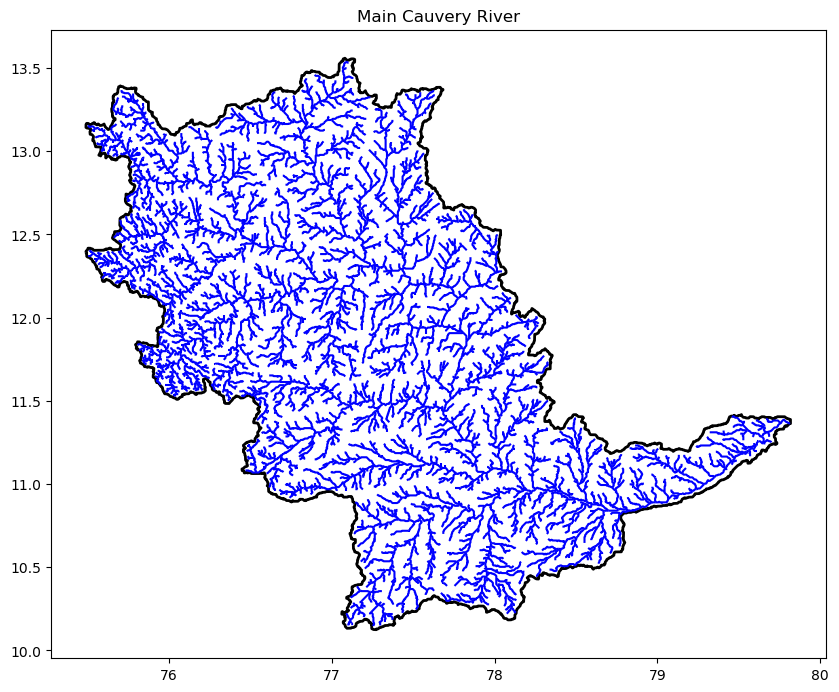

In [53]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

cauvery5.boundary.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=2
)

cauvery_rivers.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.2
)

main_river.plot(
    ax=ax,
    color="blue",
    linewidth=1.5
)

plt.title("Main Cauvery River")
plt.show()

In [ ]:
Cell 5 – Save

In [54]:
main_river.to_file(
    r"G:\OCR\hydroriver\Main_Cauvery.shp"
)

In [ ]:
Section 4.7 – Identify the Main Stem Using Stream Order

In [55]:
print(cauvery_rivers["ORD_STRA"].value_counts().sort_index())

ORD_STRA
1    2302
2    1092
3     518
4     334
5     166
6     137
Name: count, dtype: int64


In [56]:
print("Maximum Stream Order:")

print(cauvery_rivers["ORD_STRA"].max())

Maximum Stream Order:
6


In [57]:
highest_order = cauvery_rivers["ORD_STRA"].max()

main_stem = cauvery_rivers[
    cauvery_rivers["ORD_STRA"] == highest_order
]

print(main_stem.shape)

(137, 15)


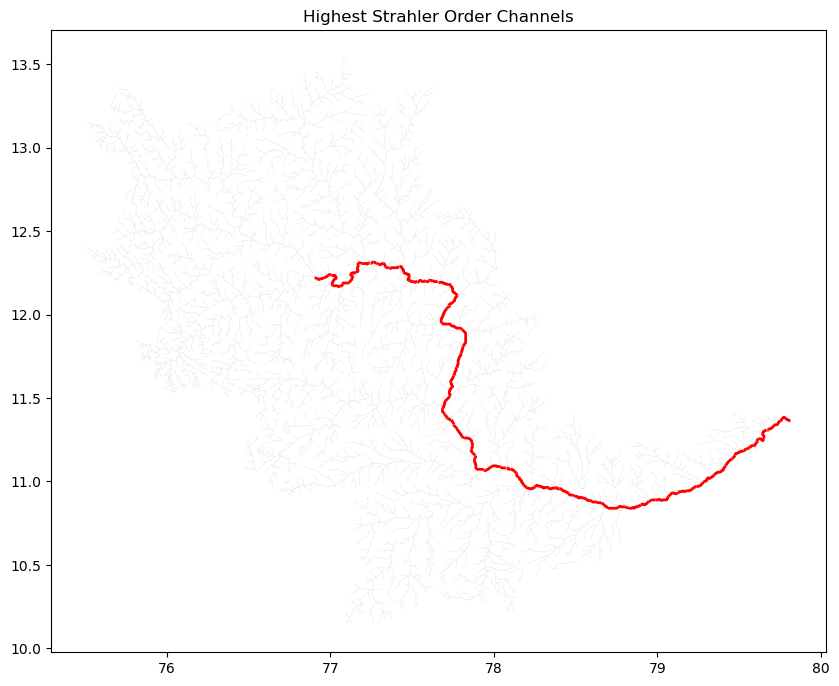

In [58]:
fig, ax = plt.subplots(figsize=(10,10))

cauvery_rivers.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.2
)

main_stem.plot(
    ax=ax,
    color="red",
    linewidth=2
)

plt.title("Highest Strahler Order Channels")
plt.show()

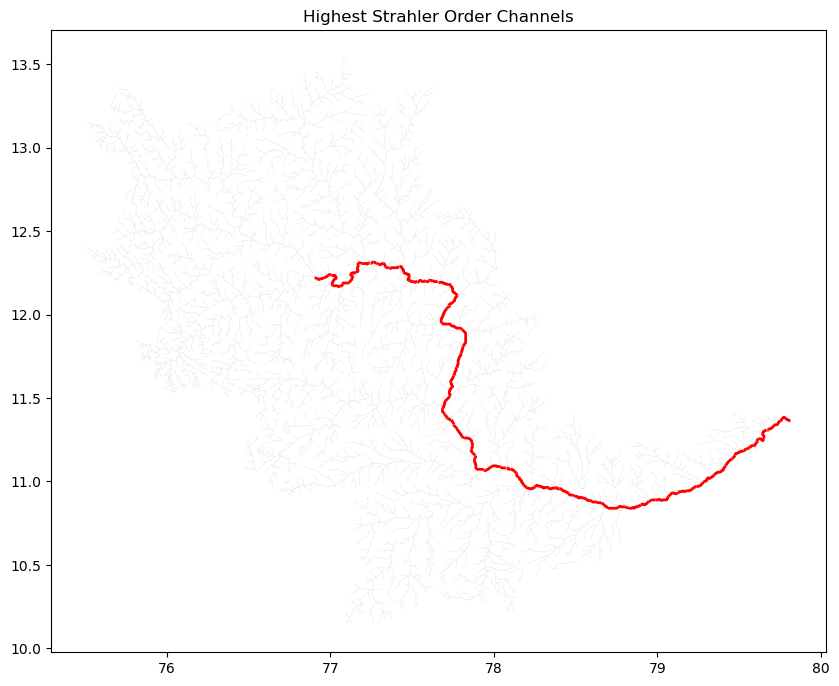

In [59]:
fig, ax = plt.subplots(figsize=(10,10))

cauvery_rivers.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.2
)

main_stem.plot(
    ax=ax,
    color="red",
    linewidth=2
)

plt.title("Highest Strahler Order Channels")
plt.show()

In [60]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cauvery_rivers = gpd.read_file(
    r"G:\OCR\hydroriver\Cauvery_Rivers.shp"
)

print("River Segments:", len(cauvery_rivers))

River Segments: 4549


In [61]:
cauvery_rivers[[
    "HYRIV_ID",
    "NEXT_DOWN",
    "LENGTH_KM",
    "ORD_STRA",
    "DIS_AV_CMS"
]].head(20)

,HYRIV_ID,NEXT_DOWN,LENGTH_KM,ORD_STRA,DIS_AV_CMS
0,41388960,41388439,9.78,1,0.521
1,41388794,41388439,5.89,1,0.310
2,41388698,41388469,5.86,1,0.277
3,41388929,41388891,0.97,1,0.140
4,41388892,41388891,0.68,1,0.132
5,41388891,41388758,2.23,2,0.321
6,41388758,41388697,1.11,2,1.018
7,41388928,41388758,3.83,1,0.600
8,41388696,41388697,5.78,1,0.445
9,41388984,41388345,10.43,1,0.647


In [62]:
duplicates = cauvery_rivers["HYRIV_ID"].duplicated().sum()

print("Duplicate HYRIV_ID:", duplicates)

Duplicate HYRIV_ID: 0


In [ ]:
Section 41.4 – Find the Outlet

In [63]:
river_ids = set(cauvery_rivers["HYRIV_ID"])

outlets = cauvery_rivers[
    ~cauvery_rivers["NEXT_DOWN"].isin(river_ids)
]

print("Outlet segments:", len(outlets))

outlets[[
    "HYRIV_ID",
    "NEXT_DOWN",
    "ORD_STRA",
    "DIS_AV_CMS",
    "LENGTH_KM"
]]

Outlet segments: 1


,HYRIV_ID,NEXT_DOWN,ORD_STRA,DIS_AV_CMS,LENGTH_KM
41,41376077,0,6,307.501,9.03


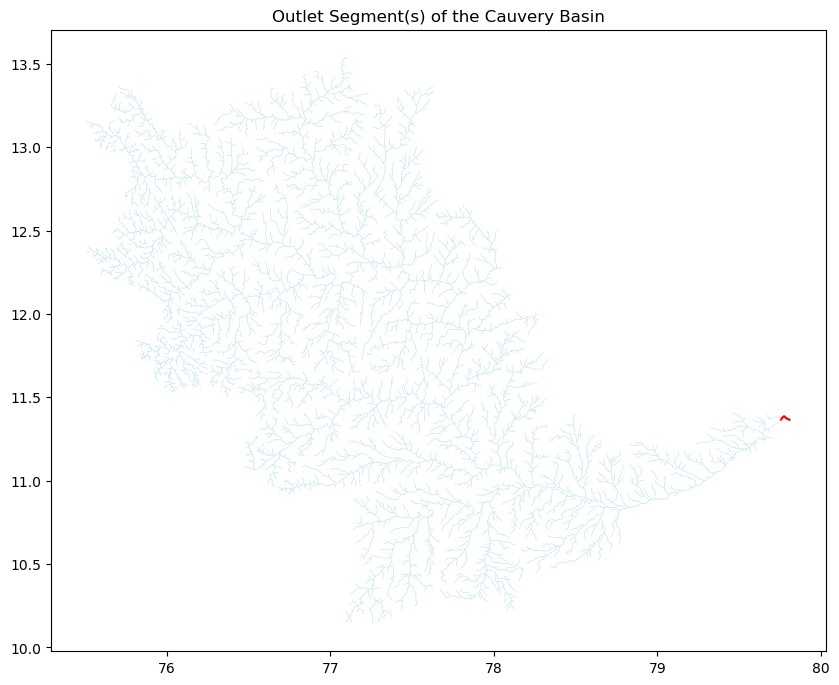

In [64]:
fig, ax = plt.subplots(figsize=(10,10))

cauvery_rivers.plot(
    ax=ax,
    color="lightblue",
    linewidth=0.3
)

outlets.plot(
    ax=ax,
    color="red",
    markersize=60
)

plt.title("Outlet Segment(s) of the Cauvery Basin")
plt.show()

In [ ]:
Section 41.6 – Build the River Connectivity Index

In [65]:
# Dictionary:
# key = downstream segment
# value = list of upstream segments

upstream = {}

for _, row in cauvery_rivers.iterrows():

    nxt = row["NEXT_DOWN"]

    hyriv = row["HYRIV_ID"]

    if nxt not in upstream:
        upstream[nxt] = []

    upstream[nxt].append(hyriv)

print("Dictionary created.")

print("Unique downstream IDs:", len(upstream))

Dictionary created.
Unique downstream IDs: 2248


In [66]:
count = 0

for k, v in upstream.items():

    print(k, " <-- ", v[:5])

    count += 1

    if count == 10:
        break

41388439  <--  [41388960, 41388794, 41388469]
41388469  <--  [41388698, 41388470]
41388891  <--  [41388929, 41388892]
41388758  <--  [41388891, 41388928]
41388697  <--  [41388758, 41388696]
41388345  <--  [41388984, 41388438]
41388437  <--  [41388697, 41388436]
41388344  <--  [41388568, 41388468]
41388216  <--  [41388437, 41388344]
41388178  <--  [41388216, 41388177]


In [67]:
outlet_id = 41376077

print("Segments flowing into the outlet:")

print(upstream[outlet_id])

Segments flowing into the outlet:
[41376732, 41376076]


In [68]:
branches = cauvery_rivers[
    cauvery_rivers["HYRIV_ID"].isin([41376732, 41376076])
]

branches[[
    "HYRIV_ID",
    "UPLAND_SKM",
    "DIS_AV_CMS",
    "ORD_STRA",
    "LENGTH_KM",
    "DIST_UP_KM",
    "DIST_DN_KM"
]]

,HYRIV_ID,UPLAND_SKM,DIS_AV_CMS,ORD_STRA,LENGTH_KM,DIST_UP_KM,DIST_DN_KM
40,41376732,78276.1,306.137,6,10.97,841.3,9.4
42,41376076,49.2,0.714,1,12.43,17.5,9.3


In [69]:
# Create a lookup dictionary by HYRIV_ID
river_lookup = cauvery_rivers.set_index("HYRIV_ID")

In [70]:
main_stem_ids = []

current = 41376077   # Outlet segment

while True:

    # Save current segment
    main_stem_ids.append(current)

    # Stop if no upstream segments
    if current not in upstream:
        break

    upstream_segments = upstream[current]

    # If only one upstream segment, continue
    if len(upstream_segments) == 1:
        current = upstream_segments[0]
        continue

    # If multiple upstream segments,
    # choose the one with the largest upstream area
    best = max(
        upstream_segments,
        key=lambda x: river_lookup.loc[x, "UPLAND_SKM"]
    )

    current = best

print("Main stem segments:", len(main_stem_ids))

Main stem segments: 207


In [71]:
main_stem = cauvery_rivers[
    cauvery_rivers["HYRIV_ID"].isin(main_stem_ids)
].copy()

print(main_stem.shape)

(207, 15)


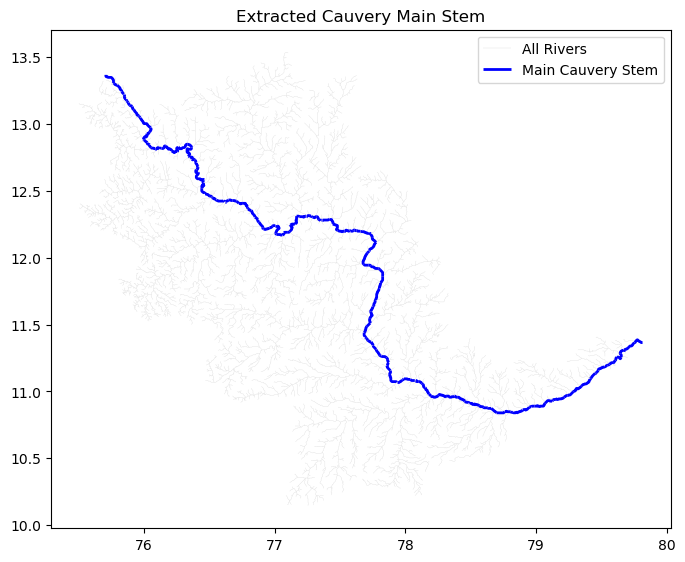

In [72]:
fig, ax = plt.subplots(figsize=(8, 12))

# Entire river network
cauvery_rivers.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.2,
    label="All Rivers"
)

# Main stem
main_stem.plot(
    ax=ax,
    color="blue",
    linewidth=2,
    label="Main Cauvery Stem"
)

plt.legend()
plt.title("Extracted Cauvery Main Stem")
plt.show()

In [ ]:
SECTION 9 – Merge the Main Stem into One Continuous River

In [ ]:
SECTION 9.1 – Import Required Function

In [73]:
# =====================================================
# SECTION 9.1 – Import Merge Function
# =====================================================

from shapely.ops import linemerge
from shapely.geometry import MultiLineString
from shapely.geometry import LineString

In [ ]:
SECTION 9.2 – Sort the River Correctly

In [74]:
# =====================================================
# SECTION 9.2 – Sort Main Stem
# =====================================================

main_stem = main_stem.sort_values(
    "DIST_DN_KM",
    ascending=False
).reset_index(drop=True)

main_stem.head()

,HYRIV_ID,NEXT_DOWN,MAIN_RIV,LENGTH_KM,DIST_DN_KM,DIST_UP_KM,CATCH_SKM,UPLAND_SKM,ENDORHEIC,DIS_AV_CMS,ORD_STRA,ORD_CLAS,ORD_FLOW,HYBAS_L12,geometry
0,41343498,41343589,41376077,11.42,826.7,13.9,48.24,48.2,0,0.896,1,2,7,4121131440,"LINESTRING (75.71042 13.36667, 75.71042 13.356..."
1,41343589,41343834,41376077,0.65,826.2,14.3,0.42,73.3,0,1.402,2,2,6,4121131440,"LINESTRING (75.76875 13.30625, 75.77292 13.30208)"
2,41343834,41344593,41376077,3.29,822.8,17.8,6.68,96.5,0,1.793,3,2,6,4121131440,"LINESTRING (75.77292 13.30208, 75.78125 13.293..."
3,41344593,41344987,41376077,6.56,816.2,24.4,23.40,160.8,0,2.687,3,2,6,4121131440,"LINESTRING (75.79792 13.28958, 75.81875 13.268..."
4,41344987,41345234,41376077,3.05,813.3,27.2,3.13,190.1,0,3.022,3,2,6,4121131440,"LINESTRING (75.83125 13.24375, 75.83542 13.239..."


In [ ]:
SECTION 9.3 – Check Geometry Type

In [75]:
# =====================================================
# SECTION 9.3 – Check Geometry
# =====================================================

print(main_stem.geometry.iloc[0])

print(type(main_stem.geometry.iloc[0]))

LINESTRING (75.71041666666636 13.366666666666468, 75.71041666666636 13.356249999999768, 75.71458333333302 13.352083333333162, 75.72291666666635 13.352083333333162, 75.72708333333301 13.347916666666457, 75.75208333333305 13.347916666666457, 75.76458333333309 13.33541666666644, 75.76458333333309 13.331249999999777, 75.76874999999976 13.327083333333128, 75.76874999999976 13.306249999999785)
<class 'shapely.geometry.linestring.LineString'>


In [ ]:
SECTION 9.4 – Merge All Segments

In [76]:
# =====================================================
# SECTION 9.4 – Merge River Segments
# =====================================================

river_line = linemerge(main_stem.geometry.tolist())

print(type(river_line))

<class 'shapely.geometry.linestring.LineString'>


In [3]:
SECTION 9.5 – Handle MultiLineString

SyntaxError: invalid character '–' (U+2013) (3584230333.py, line 1)

In [77]:
# =====================================================
# SECTION 9.5 – Convert MultiLineString
# =====================================================

if isinstance(river_line, MultiLineString):

    print("River is MultiLineString.")

    river_line = linemerge(river_line)

else:

    print("River is already a LineString.")

print(type(river_line))

River is already a LineString.
<class 'shapely.geometry.linestring.LineString'>


In [ ]:
SECTION 9.6 – Plot the River

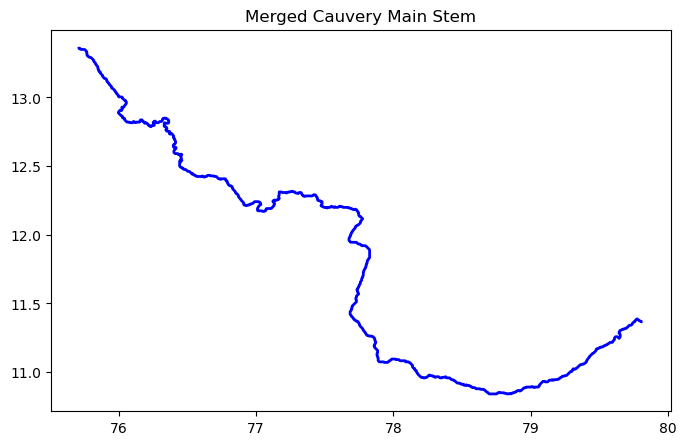

In [78]:
# =====================================================
# SECTION 9.6 – Plot Merged River
# =====================================================

fig, ax = plt.subplots(figsize=(8,12))

gpd.GeoSeries([river_line]).plot(
    ax=ax,
    linewidth=2,
    color="blue"
)

plt.title("Merged Cauvery Main Stem")

plt.show()

In [ ]:
SECTION 9.7 – Measure the River Length

In [79]:
# =====================================================
# SECTION 9.7 – River Length
# =====================================================

print("Geometry type:", river_line.geom_type)

print()

print("Length (degrees):")

print(river_line.length)

Geometry type: LineString

Length (degrees):
7.627833087664014


In [ ]:
SECTION 10 – Generate 50 km Sampling Points Along the Cauvery River

In [ ]:
SECTION 10.1 – Convert the River to a Metric Coordinate System

In [80]:
# =====================================================
# SECTION 10.1 – Convert River to UTM (Meters)
# =====================================================

river_gdf = gpd.GeoDataFrame(
    geometry=[river_line],
    crs="EPSG:4326"
)

# UTM Zone 43N
river_utm = river_gdf.to_crs(epsg=32643)

river_line_utm = river_utm.geometry.iloc[0]

print(river_utm.crs)

EPSG:32643


In [ ]:
SECTION 10.2 – Calculate the True River Length

In [81]:
# =====================================================
# SECTION 10.2 – River Length
# =====================================================

river_length = river_line_utm.length

print(f"River Length = {river_length/1000:.2f} km")

River Length = 837.26 km


In [ ]:
SECTION 10.3 – Set the Sampling Interval

In [82]:
# =====================================================
# SECTION 10.3 – Sampling Interval
# =====================================================

interval = 50000   # 50 km

print("Sampling interval:", interval/1000, "km")

Sampling interval: 50.0 km


In [ ]:
SECTION 10.4 – Generate Sampling Distances

In [83]:
# =====================================================
# SECTION 10.4 – Sampling Distances
# =====================================================

distances = np.arange(
    0,
    river_length + interval,
    interval
)

print("Number of Sampling Points:", len(distances))
print(distances)

Number of Sampling Points: 18
[     0.  50000. 100000. 150000. 200000. 250000. 300000. 350000. 400000.
 450000. 500000. 550000. 600000. 650000. 700000. 750000. 800000. 850000.]


In [ ]:
SECTION 10.5 – Create Sampling Points

In [84]:
# =====================================================
# SECTION 10.5 – Create Points
# =====================================================

points = [
    river_line_utm.interpolate(d)
    for d in distances
]

print("Points Created:", len(points))

Points Created: 18


In [ ]:
SECTION 10.6 – Create a GeoDataFrame

In [85]:
# =====================================================
# SECTION 10.6 – Create GeoDataFrame
# =====================================================

points_gdf = gpd.GeoDataFrame(
    {
        "Point_ID": range(1, len(points)+1),
        "Distance_km": distances/1000
    },
    geometry=points,
    crs=river_utm.crs
)

points_gdf.head()

,Point_ID,Distance_km,geometry
0,1,0.0,POINT (576925.658 1477794.84)
1,2,50.0,POINT (604875.649 1443257.439)
2,3,100.0,POINT (623618.935 1417364.772)
3,4,150.0,POINT (646662.507 1412299.717)
4,5,200.0,POINT (656884.759 1382288.694)


In [ ]:
SECTION 10.7 – Convert Back to WGS84

In [86]:
# =====================================================
# SECTION 10.7 – Convert to WGS84
# =====================================================

points_wgs = points_gdf.to_crs(epsg=4326)

In [ ]:
SECTION 10.8 – Plot the Sampling Points

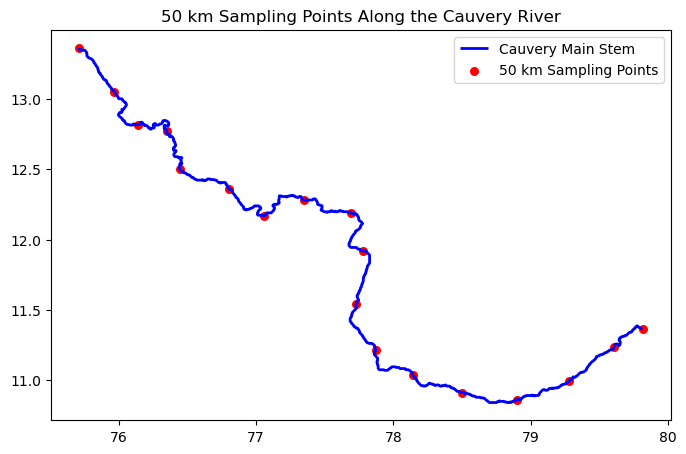

In [87]:
# =====================================================
# SECTION 10.8 – Plot Sampling Points
# =====================================================

fig, ax = plt.subplots(figsize=(8,12))

gpd.GeoSeries([river_line]).plot(
    ax=ax,
    color="blue",
    linewidth=2,
    label="Cauvery Main Stem"
)

points_wgs.plot(
    ax=ax,
    color="red",
    markersize=30,
    label="50 km Sampling Points"
)

plt.title("50 km Sampling Points Along the Cauvery River")

plt.legend()

plt.show()

In [ ]:
SECTION 10.9 – Export the Sampling Points

In [88]:
# =====================================================
# SECTION 10.9 – Export Sampling Points
# =====================================================

output = r"G:\OCR\hydroriver\Cauvery_50km_SamplingPoints.shp"

points_wgs.to_file(output)

print("Sampling points exported successfully.")

Sampling points exported successfully.


In [ ]:
SECTION 11 – Prepare Sampling Points for Google Earth Engine

In [ ]:
SECTION 11.1 – Examine the Attribute Table

In [89]:
# =====================================================
# SECTION 11.1 – Examine Sampling Points
# =====================================================

points_wgs.head(10)

,Point_ID,Distance_km,geometry
0,1,0.0,POINT (75.71042 13.36667)
1,2,50.0,POINT (75.96728 13.05355)
2,3,100.0,POINT (76.13907 12.81875)
3,4,150.0,POINT (76.35112 12.77196)
4,5,200.0,POINT (76.44375 12.50016)
5,6,250.0,POINT (76.80351 12.35899)
6,7,300.0,POINT (77.06031 12.16875)
7,8,350.0,POINT (77.34798 12.28118)
8,9,400.0,POINT (77.69462 12.18871)
9,10,450.0,POINT (77.78095 11.91875)


In [ ]:
SECTION 11.2 – Extract Coordinates

In [90]:
# =====================================================
# SECTION 11.2 – Extract Latitude & Longitude
# =====================================================

points_wgs["Longitude"] = points_wgs.geometry.x
points_wgs["Latitude"] = points_wgs.geometry.y

points_wgs.head()

,Point_ID,Distance_km,geometry,Longitude,Latitude
0,1,0.0,POINT (75.71042 13.36667),75.710417,13.366667
1,2,50.0,POINT (75.96728 13.05355),75.967285,13.053549
2,3,100.0,POINT (76.13907 12.81875),76.139072,12.818750
3,4,150.0,POINT (76.35112 12.77196),76.351122,12.771956
4,5,200.0,POINT (76.44375 12.50016),76.443750,12.500155


In [ ]:
SECTION 11.3 – Verify Coordinates

In [91]:
# =====================================================
# SECTION 11.3 – Verify Coordinates
# =====================================================

print(points_wgs[[
    "Point_ID",
    "Distance_km",
    "Longitude",
    "Latitude"
]])

    Point_ID  Distance_km  Longitude   Latitude
0          1          0.0  75.710417  13.366667
1          2         50.0  75.967285  13.053549
2          3        100.0  76.139072  12.818750
3          4        150.0  76.351122  12.771956
4          5        200.0  76.443750  12.500155
5          6        250.0  76.803512  12.358988
6          7        300.0  77.060307  12.168750
7          8        350.0  77.347982  12.281185
8          9        400.0  77.694625  12.188709
9         10        450.0  77.780955  11.918750
10        11        500.0  77.731250  11.544386
11        12        550.0  77.871036  11.216464
12        13        600.0  78.139583  11.036732
13        14        650.0  78.501841  10.910417
14        15        700.0  78.899609  10.860417
15        16        750.0  79.278385  10.990886
16        17        800.0  79.607195  11.232195
17        18        850.0  79.814583  11.364583


In [ ]:
SECTION 11.4 – Save as Shapefile

In [92]:
# =====================================================
# SECTION 11.4 – Export Shapefile
# =====================================================

output = r"G:\OCR\hydroriver\Cauvery_50km_SamplingPoints.shp"

points_wgs.to_file(output)

print("Shapefile exported successfully.")

Shapefile exported successfully.


In [ ]:
SECTION 11.5 – Save as GeoJSON

In [93]:
# =====================================================
# SECTION 11.5 – Export GeoJSON
# =====================================================

geojson = r"G:\OCR\hydroriver\Cauvery_50km_SamplingPoints.geojson"

points_wgs.to_file(
    geojson,
    driver="GeoJSON"
)

print("GeoJSON exported successfully.")

GeoJSON exported successfully.


In [ ]:
SECTION 11.6 – Save as CSV

In [94]:
# =====================================================
# SECTION 11.6 – Export CSV
# =====================================================

csv_file = r"G:\OCR\hydroriver\Cauvery_50km_SamplingPoints.csv"

points_wgs.drop(columns="geometry").to_csv(
    csv_file,
    index=False
)

print("CSV exported successfully.")

CSV exported successfully.


In [ ]:
SECTION 12.1 – Upload the Shapefile

In [ ]:
SECTION 12.2 – Import the Asset

In [95]:
ee.FeatureCollection("projects/oc-flux/assets/Cauvery_50km_Points")

In [ ]:
Display the Sampling Points

In [97]:
# =====================================================
# SECTION 12.1 – Display Sampling Points
# =====================================================

Map = geemap.Map()

Map.centerObject(points, 8)

Map.addLayer(
    points,
    {"color": "red"},
    "50 km Sampling Points"
)

Map

Map(center=[11.923941212512156, 77.6221773134291], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
Count the Sampling Points

In [98]:
# =====================================================
# SECTION 12.2 – Number of Sampling Points
# =====================================================

print("Number of Sampling Points:")

print(points.size().getInfo())

Number of Sampling Points:
18


In [ ]:
Inspect the First Point

In [99]:
# =====================================================
# SECTION 12.3 – First Sampling Point
# =====================================================

first_point = points.first()

print(first_point.getInfo())

{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [75.71041666666636, 13.366666666666466]}, 'id': '0', 'properties': {'Distance_k': 0, 'Latitude': 13.366666666666466, 'Longitude': 75.71041666666636, 'Point_ID': 1}}


In [ ]:
Display Point Attributes

In [108]:
# =====================================================
# SECTION 12.4 – Display Attributes
# =====================================================

points_info = points.getInfo()

for feature in points_info["features"]:

    print(feature["properties"])

{'Distance_k': 0, 'Latitude': 13.366666666666466, 'Longitude': 75.71041666666636, 'Point_ID': 1}
{'Distance_k': 50, 'Latitude': 13.053548632071127, 'Longitude': 75.96728478805915, 'Point_ID': 2}
{'Distance_k': 100, 'Latitude': 12.818750061450949, 'Longitude': 76.1390720041158, 'Point_ID': 3}
{'Distance_k': 150, 'Latitude': 12.771955634969824, 'Longitude': 76.35112225725183, 'Point_ID': 4}
{'Distance_k': 200, 'Latitude': 12.50015510335735, 'Longitude': 76.443749992942, 'Point_ID': 5}
{'Distance_k': 250, 'Latitude': 12.358987737083945, 'Longitude': 76.80351234165879, 'Point_ID': 6}
{'Distance_k': 300, 'Latitude': 12.168750002461435, 'Longitude': 77.06030702542073, 'Point_ID': 7}
{'Distance_k': 350, 'Latitude': 12.281184991262812, 'Longitude': 77.34798167672137, 'Point_ID': 8}
{'Distance_k': 400, 'Latitude': 12.188708706743439, 'Longitude': 77.694624640407, 'Point_ID': 9}
{'Distance_k': 450, 'Latitude': 11.91875018295846, 'Longitude': 77.78095498070532, 'Point_ID': 10}
{'Distance_k': 500,

In [ ]:
Add the Cauvery Main Stem

In [109]:
# =====================================================
# SECTION 12.5 – Load Main Cauvery River
# =====================================================

river = geemap.shp_to_ee(
    r"G:\OCR\hydroriver\Main_Cauvery.shp"
)

Map.addLayer(
    river,
    {
        "color": "blue"
    },
    "Main Cauvery"
)

Map

Map(bottom=15588.0, center=[11.953349393643416, 79.30480957031251], controls=(WidgetControl(options=['position…

In [ ]:
SECTION 13 – Load Landsat Collection and Visualize Imagery

In [ ]:
SECTION 13.1 – Load the Main Cauvery River

In [114]:
# =====================================================
# SECTION 13.1 – Load Main Cauvery River
# =====================================================

river = geemap.shp_to_ee(
    r"G:\OCR\hydroriver\Main_Cauvery.shp"
)

Map = geemap.Map()

Map.addLayer(
    river,
    {"color":"blue"},
    "Main Cauvery"
)

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
SECTION 13.2 – Add the Sampling Points

In [115]:
# =====================================================
# SECTION 13.2 – Add Sampling Points
# =====================================================

Map.addLayer(
    points,
    {"color":"red"},
    "50 km Sampling Points"
)

Map

Map(bottom=812.0, center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [116]:
SECTION 13.3 – Load Landsat 8 Collection

SyntaxError: invalid character '–' (U+2013) (4147716245.py, line 1)

In [117]:
# =====================================================
# SECTION 13.3 – Landsat Collection
# =====================================================

landsat = ee.ImageCollection(
    "LANDSAT/LC08/C02/T1_L2"
)

In [ ]:
SECTION 13.4 – Filter by Rive

In [118]:
# =====================================================
# SECTION 13.4 – Filter by River
# =====================================================

landsat = landsat.filterBounds(river)

In [ ]:
SECTION 13.5 – Filter by Date

In [119]:
# =====================================================
# SECTION 13.5 – Filter by Date
# =====================================================

landsat = landsat.filterDate(
    "2023-01-01",
    "2023-12-31"
)

In [ ]:
SECTION 13.6 – Remove Cloudy Images

In [120]:
# =====================================================
# SECTION 13.6 – Cloud Filter
# =====================================================

landsat = landsat.filter(
    ee.Filter.lt("CLOUD_COVER", 20)
)

In [ ]:
SECTION 13.7 – Count Images

In [121]:
# =====================================================
# SECTION 13.7 – Number of Images
# =====================================================

print(
    "Images Found:",
    landsat.size().getInfo()
)

Images Found: 76


In [ ]:
SECTION 13.8 – Display First Image

In [124]:
# =====================================================
# SECTION 13.8 – Display First Image
# =====================================================

image = landsat.first()

Map.centerObject(
    river,
    8
)

Map.addLayer(
    image,
    {
        "bands":["SR_B4","SR_B3","SR_B2"],
        "min":7000,
        "max":15000
    },
    "Landsat RGB"
)

Map

Map(bottom=30899.0, center=[11.82734269115227, 77.21707593703306], controls=(WidgetControl(options=['position'…

In [ ]:
SECTION 14 – Cloud Masking and Surface Reflectance Preparation

In [130]:
# =====================================================
# SECTION 14.1 – Cloud Mask Function
# =====================================================

def mask_landsat(image):
    """
    Masks clouds, cloud shadows and saturated pixels
    for Landsat Collection 2 Level-2.
    """

    qa = image.select("QA_PIXEL")

    cloud_shadow = 1 << 4
    snow = 1 << 5
    cloud = 1 << 3

    mask = (
        qa.bitwiseAnd(cloud_shadow).eq(0)
        .And(qa.bitwiseAnd(cloud).eq(0))
        .And(qa.bitwiseAnd(snow).eq(0))
    )

    saturation = image.select("QA_RADSAT").eq(0)

    return (
        image
        .updateMask(mask)
        .updateMask(saturation)
    )

In [131]:
# =====================================================
# SECTION 14.2 – Apply Cloud Mask
# =====================================================

landsat_masked = landsat.map(mask_landsat)

print(
    "Masked Images:",
    landsat_masked.size().getInfo()
)

Masked Images: 76


In [133]:
# =====================================================
# SECTION 14.3 – Scale Reflectance
# =====================================================

def apply_scale(image):

    optical = (
        image
        .select("SR_B.*")
        .multiply(0.0000275)
        .add(-0.2)
    )

    return image.addBands(
        optical,
        overwrite=True
    )

In [134]:
# =====================================================
# SECTION 14.4 – Apply Scale Factors
# =====================================================

landsat_sr = landsat_masked.map(apply_scale)

print(
    "Scaled Collection:",
    landsat_sr.size().getInfo()
)

Scaled Collection: 76


In [135]:
# =====================================================
# SECTION 14.5 – Display Processed Image
# =====================================================

image = landsat_sr.first()

Map = geemap.Map()

Map.centerObject(river, 8)

Map.addLayer(
    image,
    {
        "bands": ["SR_B4", "SR_B3", "SR_B2"],
        "min": 0,
        "max": 0.3
    },
    "Scaled Surface Reflectance"
)

Map.addLayer(
    river,
    {"color": "blue"},
    "Main Cauvery"
)

Map.addLayer(
    points,
    {"color": "red"},
    "Sampling Points"
)

Map

Map(center=[11.82734269115226, 77.21707593703307], controls=(WidgetControl(options=['position', 'transparent_b…

In [137]:
# =====================================================
# SECTION 14.6 – Inspect Band Information
# =====================================================

band_names = image.bandNames().getInfo()

print("Bands:")

print(band_names)

Bands:
['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT']


In [ ]:
SECTION 15 – Extract Mean Surface Reflectance Using a 60 m Buffer

In [147]:
# =====================================================
# SECTION 15.1 – Create 60 m Buffers
# =====================================================

buffer_distance = 60   # metres

points_buffer = points.map(
    lambda f: f.buffer(buffer_distance)
)

print("Buffered points created.")

Buffered points created.


In [148]:
# =====================================================
# SECTION 15.2 – Display Buffers
# =====================================================

Map = geemap.Map()

Map.centerObject(river, 8)

Map.addLayer(
    river,
    {"color":"blue"},
    "Main Cauvery"
)

Map.addLayer(
    points_buffer,
    {"color":"yellow"},
    "60 m Buffer"
)

Map

Map(center=[11.82734269115226, 77.21707593703307], controls=(WidgetControl(options=['position', 'transparent_b…

In [149]:
# =====================================================
# SECTION 15.3 – Extract Mean Reflectance
# =====================================================

def extract_buffer_reflectance(image):

    date = image.date().format("YYYY-MM-dd")

    result = image.reduceRegions(
        collection=points_buffer,
        reducer=ee.Reducer.mean(),
        scale=30
    )

    result = result.map(
        lambda f: f.set("Date", date)
    )

    return result

In [150]:
# =====================================================
# SECTION 15.4 – Extract from All Images
# =====================================================

reflectance = (
    landsat_selected
    .map(extract_buffer_reflectance)
    .flatten()
)

print("Extraction Finished")

Extraction Finished


In [151]:
# =====================================================
# SECTION 15.5 – Number of Samples
# =====================================================

print(
    "Total Samples:",
    reflectance.size().getInfo()
)

Total Samples: 1368


In [ ]:
SECTION 16 – Convert Earth Engine Results to a Pandas DataFrame

In [152]:
# =====================================================
# SECTION 16.1 – Convert FeatureCollection
# =====================================================

reflectance_dict = reflectance.getInfo()

print("Conversion Complete")

Conversion Complete


In [153]:
features = reflectance_dict["features"]

print("Number of Features:", len(features))

Number of Features: 1368


In [154]:
import pandas as pd

records = []

for feature in features:

    props = feature["properties"]

    records.append(props)

df = pd.DataFrame(records)

print(df.shape)

df.head()

(1368, 11)


,Date,Distance_k,Latitude,Longitude,Point_ID,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7
0,2023-02-22,0,13.366667,75.710417,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-02-22,50,13.053549,75.967285,2,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-02-22,100,12.818750,76.139072,3,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-02-22,150,12.771956,76.351122,4,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-02-22,200,12.500155,76.443750,5,NaN,NaN,NaN,NaN,NaN,NaN


In [155]:
print(df.columns.tolist())

['Date', 'Distance_k', 'Latitude', 'Longitude', 'Point_ID', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']


In [156]:
output_csv = r"G:\OCR\hydroriver\Cauvery_Reflectance_2023.csv"

df.to_csv(output_csv, index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
Section 17

In [157]:
# =====================================================
# SECTION 17.1 – Dataset Overview
# =====================================================

print(df.shape)

df.head()

(1368, 11)


,Date,Distance_k,Latitude,Longitude,Point_ID,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7
0,2023-02-22,0,13.366667,75.710417,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-02-22,50,13.053549,75.967285,2,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-02-22,100,12.818750,76.139072,3,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-02-22,150,12.771956,76.351122,4,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-02-22,200,12.500155,76.443750,5,NaN,NaN,NaN,NaN,NaN,NaN


In [158]:
# =====================================================
# SECTION 17.2 – Data Types
# =====================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1368 entries, 0 to 1367
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        1368 non-null   str    
 1   Distance_k  1368 non-null   int64  
 2   Latitude    1368 non-null   float64
 3   Longitude   1368 non-null   float64
 4   Point_ID    1368 non-null   int64  
 5   SR_B2       228 non-null    float64
 6   SR_B3       228 non-null    float64
 7   SR_B4       228 non-null    float64
 8   SR_B5       228 non-null    float64
 9   SR_B6       228 non-null    float64
 10  SR_B7       228 non-null    float64
dtypes: float64(8), int64(2), str(1)
memory usage: 117.7 KB


In [159]:
# =====================================================
# SECTION 17.3 – Missing Values
# =====================================================

print(df.isnull().sum())

Date             0
Distance_k       0
Latitude         0
Longitude        0
Point_ID         0
SR_B2         1140
SR_B3         1140
SR_B4         1140
SR_B5         1140
SR_B6         1140
SR_B7         1140
dtype: int64


In [160]:
# =====================================================
# SECTION 17.4 – Summary Statistics
# =====================================================

df.describe()

,Distance_k,Latitude,Longitude,Point_ID,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7
count,1368.000000,1368.000000,1368.000000,1368.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000
mean,425.000000,11.921308,77.619028,9.500000,0.036823,0.066457,0.064303,0.177207,0.141303,0.091281
std,259.501238,0.778750,1.223510,5.190025,0.021961,0.026601,0.037066,0.097336,0.090526,0.066362
min,0.000000,10.860417,75.710417,1.000000,-0.148461,-0.045364,-0.058704,-0.026228,0.002633,0.002431
25%,200.000000,11.216464,76.443750,5.000000,0.026073,0.049237,0.036993,0.102503,0.074763,0.038949
50%,425.000000,12.043750,77.712937,9.500000,0.035697,0.061972,0.057820,0.188668,0.134600,0.085980
75%,650.000000,12.500155,78.501841,14.000000,0.046088,0.079929,0.084771,0.253308,0.207994,0.131567
max,850.000000,13.366667,79.814583,18.000000,0.094482,0.150172,0.180336,0.400619,0.328227,0.292222


In [164]:
for root, dirs, files in os.walk(folder):
    print(root)
    for f in files:
        print("   ", f)